#### Feature Selection via Jensen Shannon Divergence
#### Applied to Breast Cancer Wisconsin Dataset

**Goal:** Use KDE-based JS divergence to rank features by their class-separability, then compare Logistic Regression performance before and after feature selection.

### Dependencies

In [151]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import set_config

set_config(display="text")
sns.set_theme(style="whitegrid", palette="muted")

### Load Data

In [152]:
cancer_ds = load_breast_cancer()
feature_names = cancer_ds.feature_names

cancer_df = pd.DataFrame(cancer_ds.data, columns=feature_names)
cancer_df["target"] = cancer_ds.target
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### EDA

Quick look at a few features to get an intuition for class separation.

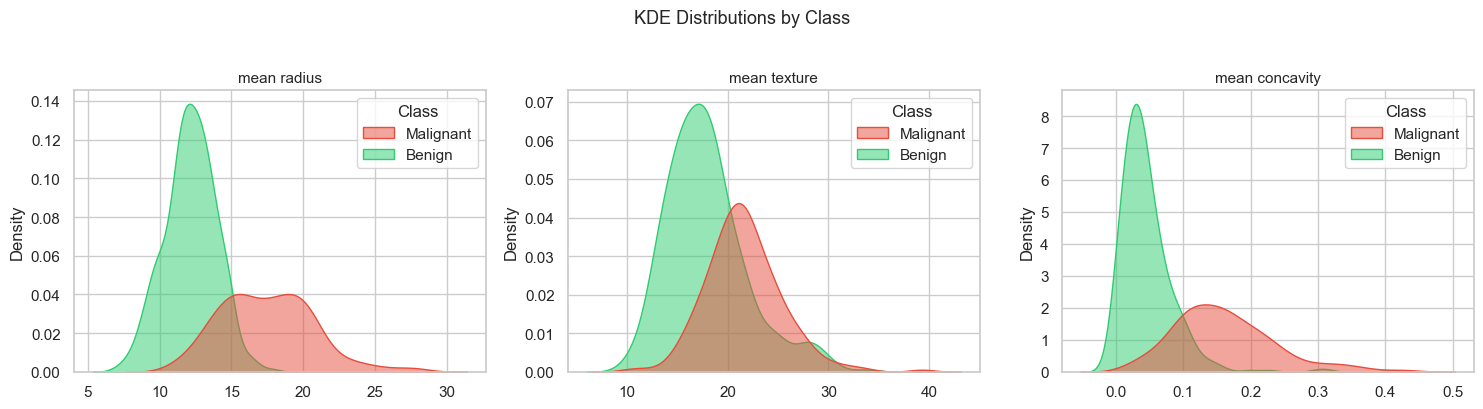

In [153]:
preview_features = ["mean radius", "mean texture", "mean concavity"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, preview_features):
    sns.kdeplot(
        data=cancer_df, x=feat, hue="target",
        fill=True, alpha=0.5, ax=ax,
        palette={0: "#e74c3c", 1: "#2ecc71"}
    )
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("")
    handles = ax.get_legend().legend_handles
    ax.legend(handles, ["Malignant", "Benign"], title="Class")

plt.suptitle("KDE Distributions by Class", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Jensen-Shannon Divergence per Feature

$$JS(P \| Q) = \frac{1}{2} KL(P \| M) + \frac{1}{2} KL(Q \| M), \quad M = \frac{P+Q}{2}$$

We estimate each class distribution with Gaussian KDE, then integrate numerically over a shared grid.

In [154]:
def compute_js_divergence(df, features, target_col: str = "target") -> pd.DataFrame:

    EPS = 1e-12      # for stability
    N_POINTS = 1000  
    results = []

    for feat in features:
        grp0 = df[df[target_col] == 0][feat].dropna()
        grp1 = df[df[target_col] == 1][feat].dropna()

        kde0 = gaussian_kde(grp0)
        kde1 = gaussian_kde(grp1)
        min_val=min(grp0.min(), grp1.min())
        max_val=max(grp0.max(), grp1.max())

        x = np.linspace(min_val,max_val,N_POINTS)
        dx = x[1] - x[0]

        p = kde0(x)
        q = kde1(x)
        m = 0.5 * (p + q)

        kl_pm = np.sum(p * np.log((p + EPS) / (m + EPS))) * dx
        kl_qm = np.sum(q * np.log((q + EPS) / (m + EPS))) * dx
        js = 0.5 * (kl_pm + kl_qm)

        results.append({"feature": feat, "js_divergence": js})

    return pd.DataFrame(results)



In [155]:
js_scores = compute_js_divergence(cancer_df, list(feature_names))
print(f"JS divergence computed for {len(js_scores)} features")

js_scores.sort_values("js_divergence", ascending=False)

JS divergence computed for 30 features


,feature,js_divergence
22,worst perimeter,0.454816
20,worst radius,0.437327
27,worst concave points,0.428809
23,worst area,0.421054
7,mean concave points,0.413528
2,mean perimeter,0.374883
0,mean radius,0.354020
3,mean area,0.350285
13,area error,0.345220
6,mean concavity,0.332747


### More EDA

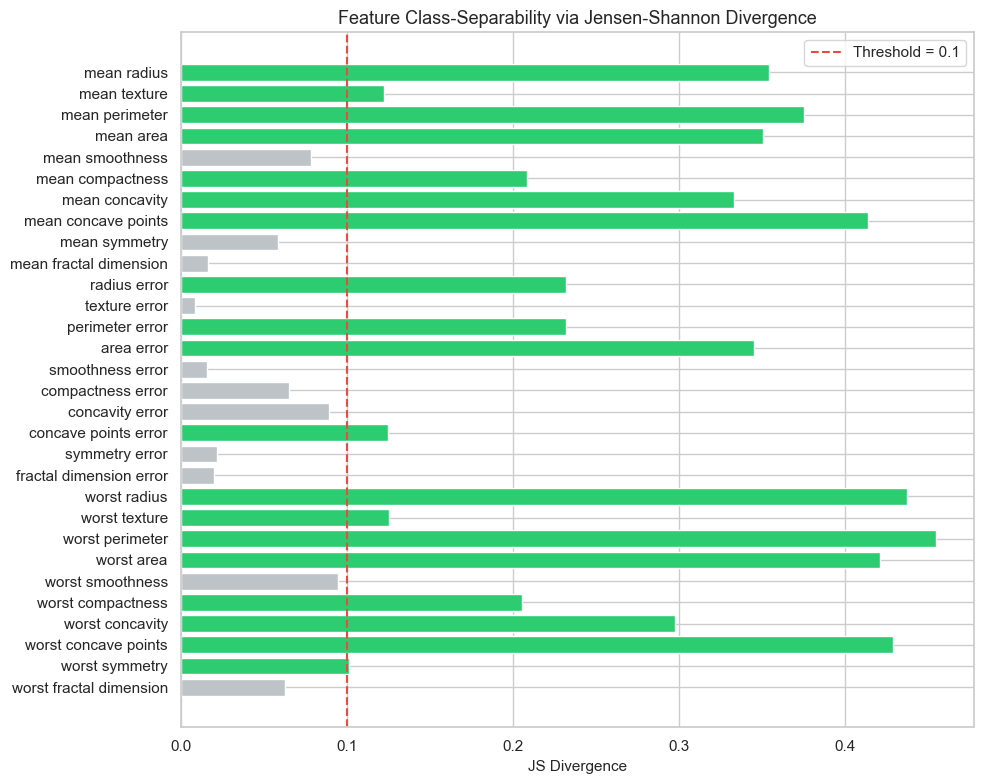

Features kept  : 19 / 30
Features dropped: 11
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean compactness' 'mean concavity' 'mean concave points' 'radius error'
 'perimeter error' 'area error' 'concave points error' 'worst radius'
 'worst texture' 'worst perimeter' 'worst area' 'worst compactness'
 'worst concavity' 'worst concave points' 'worst symmetry']


In [156]:
JS_THRESHOLD = 0.1  # threshold value for seperation

colors = ["#2ecc71" if v > JS_THRESHOLD else "#bdc3c7" for v in js_scores["js_divergence"]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(js_scores["feature"][::-1], js_scores["js_divergence"][::-1], color=colors[::-1])
ax.axvline(JS_THRESHOLD, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Threshold = {JS_THRESHOLD}")
ax.set_xlabel("JS Divergence", fontsize=11)
ax.set_title("Feature Class-Separability via Jensen-Shannon Divergence", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

kept_features = js_scores[js_scores["js_divergence"] > JS_THRESHOLD]["feature"].values
print(f"Features kept  : {len(kept_features)} / {len(feature_names)}")
print(f"Features dropped: {len(feature_names) - len(kept_features)}")
print(kept_features)

### KDE Plots for Top JS Features

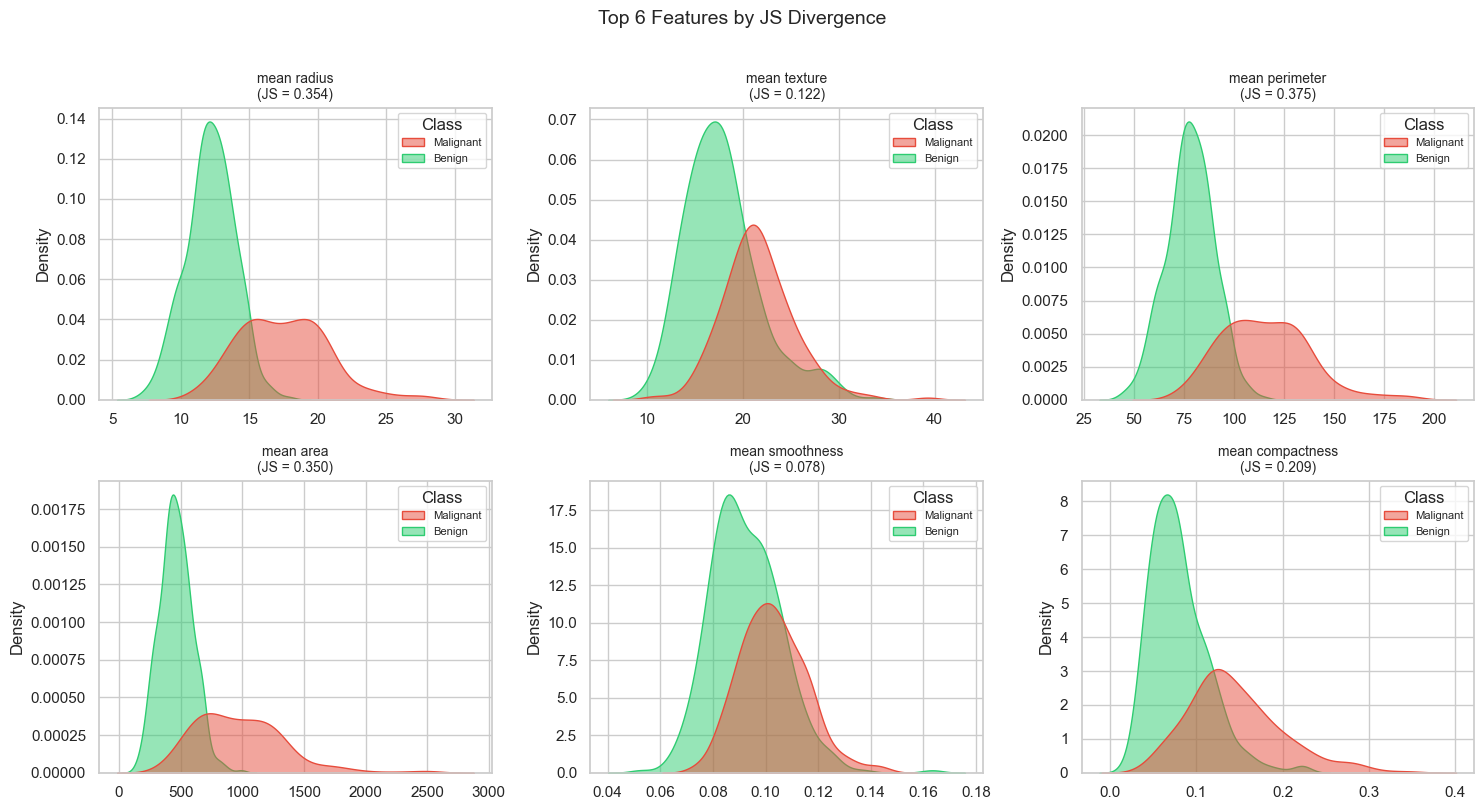

In [157]:
TOP_N = 6
top_features = js_scores.head(TOP_N)["feature"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    sns.kdeplot(
        data=cancer_df, x=feat, hue="target",
        fill=True, alpha=0.5, ax=ax,
        palette={0: "#e74c3c", 1: "#2ecc71"}
    )
    js_val = js_scores.loc[js_scores["feature"] == feat, "js_divergence"].values[0]
    ax.set_title(f"{feat}\n(JS = {js_val:.3f})", fontsize=10)
    ax.set_xlabel("")
    handles = ax.get_legend().legend_handles
    ax.legend(handles, ["Malignant", "Benign"], title="Class", fontsize=8)

plt.suptitle(f"Top {TOP_N} Features by JS Divergence", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Model Training & Evaluation


Evaluation: 75/25 stratified hold-out + 5-fold stratified cross-validation.

In [158]:
RANDOM_STATE = 201

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def build_model():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression( random_state=RANDOM_STATE))
    ])


def run_eval(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
    )

    model = build_model().fit(X_train, y_train)

    holdout_acc = model.score(X_test, y_test)
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

    print(f"\n{name}  features = {X.shape[1]}")
    print(f"Holdout: {holdout_acc:.4f}")
    print(f"CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    return {
        "Model": name,
        "Features": X.shape[1],
        "Holdout": holdout_acc,
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std()
    }


X_all = cancer_df[feature_names]
X_sel = cancer_df[kept_features]
y = cancer_df["target"]

res_all = run_eval(X_all, y, "All Features")
res_sel = run_eval(X_sel, y, "JS Selected")


All Features  features = 30
Holdout: 0.9790
CV: 0.9737 ± 0.0124

JS Selected  features = 19
Holdout: 0.9790
CV: 0.9684 ± 0.0197
